# Author prediction using RNNs

In this notebook, you will prepare a dataset to predict authorship of the Federalist Papers using Recurrent Neural Networks (RNNs).

## Federalist Papers

The Federalist Papers are a collection of 85 articles and essays written by Alexander Hamilton, James Madison, and John Jay under the pseudonym "Publius". They were published in 1787 and 1788 to promote the ratification of the United States Constitution. The authors of the Federalist Papers wanted to remain anonymous, so they used the pseudonym "Publius". The articles were published in two newspapers, the New York Packet and the Independent Journal. The Federalist Papers are considered important works of American political thought and are still widely read today.

## Additional information

- [Federalist Papers](https://en.wikipedia.org/wiki/The_Federalist_Papers)
- [Federalist Papers dataset](https://www.kaggle.com/datasets/tobyanderson/federalist-papers)
- [LOC Research Guide](https://guides.loc.gov/federalist-papers/full-text)

## Objectives (a)

- Task 1: Design your dataset to predict the author of a text using RNNs.
- Task 2: Explain the methodology of your dataset creation.
- Task 3: Establish a baseline model using Machine Learning algorithms (SVM, Random Forest, etc.).
  
## Objectives (b)

- Task 4: Train a RNN model to predict the author of a text.
- Task 5: Evaluate the performance of your model.
- Task 6: Explain your model architecture, hyperparameters, and the results of your model.

## Task 1: Dataset Creation

### Dataset description

Use the below code to scrape the Library of Congress research guide for the Federalist Papers. You need to pip install the following for the below code to work:

- `pip install beautifulsoup4`
- `pip install requests`
- `pip install pandas`

In [ ]:
!pip install beautifulsoup4
!pip install requests
!pip install pandas

In [ ]:
!pip install nltk

In [ ]:
import pandas as pd
from io import StringIO
from bs4 import BeautifulSoup as bs
import requests

url = 'https://guides.loc.gov/federalist-papers/full-text'

html = requests.get(url).text
soup = bs(html, 'html.parser')


table = soup.find('table')

meta_df = pd.read_html(StringIO(str(table)), parse_dates=True)[0]

### Dataset datatypes

In [ ]:
meta_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No.          85 non-null     float64
 1   Title        85 non-null     object 
 2   Author       85 non-null     object 
 3   Publication  85 non-null     object 
 4   Date         85 non-null     object 
dtypes: float64(1), object(4)
memory usage: 3.4+ KB


In [ ]:
meta_df #There are 85 total federalist papers

,No.,Title,Author,Publication,Date
0,1.0,General Introduction,Hamilton,For the Independent Journal,--
1,2.0,Concerning Dangers from Foreign Force and Infl...,Jay,For the Independent Journal,--
2,3.0,The Same Subject Continued: Concerning Dangers...,Jay,For the Independent Journal,--
3,4.0,The Same Subject Continued: Concerning Dangers...,Jay,For the Independent Journal,--
4,5.0,The Same Subject Continued: Concerning Dangers...,Jay,For the Independent Journal,--
...,...,...,...,...,...
80,81.0,"The Judiciary Continued, and the Distribution ...",Hamilton,From McLEAN's Edition,--
81,82.0,The Judiciary Continued,Hamilton,From McLEAN's Edition,--
82,83.0,The Judiciary Continued in Relation to Trial b...,Hamilton,From McLEAN's Edition,--
83,84.0,Certain General and Miscellaneous Objections t...,Hamilton,From McLEAN's Edition,--


In [ ]:
meta_df['Title'].head(50)

0                                  General Introduction
1     Concerning Dangers from Foreign Force and Infl...
2     The Same Subject Continued: Concerning Dangers...
3     The Same Subject Continued: Concerning Dangers...
4     The Same Subject Continued: Concerning Dangers...
5     Concerning Dangers from Dissensions Between th...
6     The Same Subject Continued: Concerning Dangers...
7     The Consequences of Hostilities Between the St...
8     The Union as a Safeguard Against Domestic Fact...
9     The Same Subject Continued: The Union as a Saf...
10    The Utility of the Union in Respect to Commerc...
11       The Utility of the Union in Respect to Revenue
12    Advantage of the Union in Respect to Economy i...
13    Objections to the Proposed Constitution from E...
14    The Insufficiency of the Present Confederation...
15    The Same Subject Continued: The Insufficiency ...
16    The Same Subject Continued: The Insufficiency ...
17    The Same Subject Continued: The Insufficie

### Authorship counts

Plot the count the number of papers written by each author. We want to create a machine learning dataset that consists of a train, validation, and test set. We will use the train set to train the model, the validation set to tune the hyperparameters, and the test set to evaluate the model.

Plotting the count of papers.

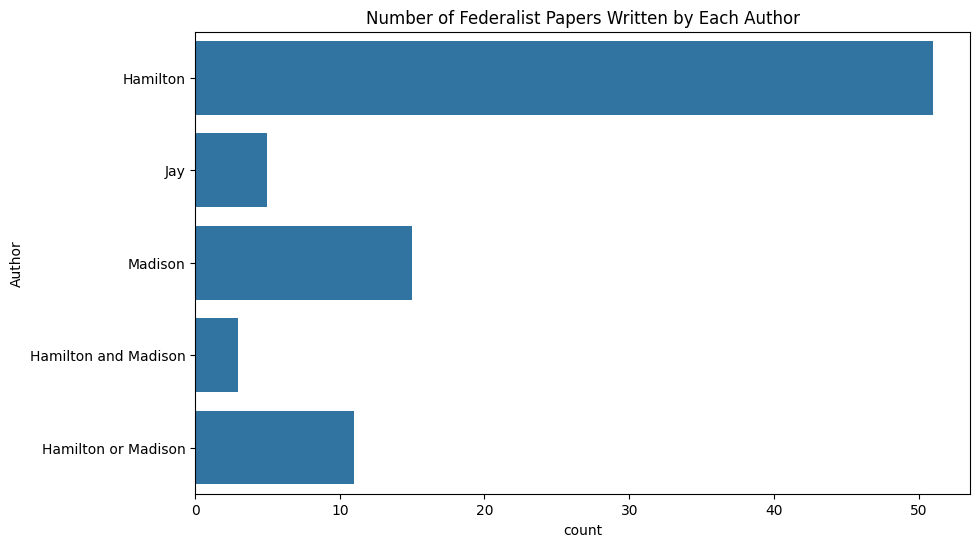

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(y='Author', data=meta_df)
plt.title('Number of Federalist Papers Written by Each Author')
plt.show()

Based on the data, answer the following questions:

- How many papers were written by each author?
- How should you construct your dataset? Explain your reasoning.

**According to the graph, Hamilton alone has wrote the most with a little over 50 papers, "Hamilton or Madison" wrote a little over 10, "Hamilton and Madison" have around 2 or 3, Madison has around 15, and Jay has around 5. In constructing my dataset, I plan to just clean the text like we have done in class previously. This includes lemmatizing and tokenizing. After I will tag and frequently observe how the data changes and what patterns I can spot.**

In [ ]:
author_counts = meta_df['Author'].value_counts()
author_counts

Author
Hamilton                51
Madison                 15
Hamilton or Madison     11
Jay                      5
Hamilton and Madison     3
Name: count, dtype: int64

### Contested authorship

In [ ]:
disputed_papers = meta_df[meta_df['Author'] == 'Hamilton or Madison'] #Going to create a new DataFrame disputed_papers containing only those rows where the value in the 'Author' column is 'Hamilton or Madison'
contested_authorship = disputed_papers['No.'].values #What number every part of this dataframe is
print(f'Contested authorship of papers: {contested_authorship}') #Listening these numbers
print(f'Total number of disputed papers: {len(disputed_papers)}') #Listing the amounts of numbers

Contested authorship of papers: [49. 50. 51. 52. 53. 54. 55. 56. 57. 62. 63.]
Total number of disputed papers: 11


In [ ]:
disputed_papers #These are the disputed papers: Hamilton or Madisons

,No.,Title,Author,Publication,Date
48,49.0,Method of Guarding Against the Encroachments o...,Hamilton or Madison,From the New York Packet,"Tuesday, February 5, 1788"
49,50.0,Periodic Appeals to the People Considered,Hamilton or Madison,From the New York Packet,"Tuesday, February 5, 1788"
50,51.0,The Structure of the Government Must Furnish t...,Hamilton or Madison,From the New York Packet,"Friday, February 8, 1788"
51,52.0,The House of Representatives,Hamilton or Madison,From the New York Packet,"Friday, February 8, 1788"
52,53.0,The Same Subject Continued: The House of Repre...,Hamilton or Madison,From the New York Packet,"Tuesday, February 12, 1788"
53,54.0,The Apportionment of Members Among States,Hamilton or Madison,From the New York Packet,"Tuesday, February 12, 1788"
54,55.0,The Total Number of the House of Representatives,Hamilton or Madison,From the New York Packet,"Friday, February 15, 1788"
55,56.0,The Same Subject Continued: The Total Number o...,Hamilton or Madison,From the New York Packet,"Tuesday, February 19, 1788"
56,57.0,The Alleged Tendency of the Plan to Elevate th...,Hamilton or Madison,From the New York Packet,"Tuesday, February 19, 1788"
61,62.0,The Senate,Hamilton or Madison,For the Independent Journal,--


### Load the Federalist Papers corpus

The following code loads the Federalist Papers corpus. The papers have been preprocessed to aid your analysis of the authorship of the papers.

In [ ]:
import os

IN_COLAB = False

try:
    import google.colab
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive', force_remount=True)
    data_dir = "/content/drive/MyDrive/Gelila_WM/Natural_Language_Processing/Datasets/Federalist_Papers"
else:
    data_dir = "../Federalist_Papers"

os.listdir(data_dir)

Mounted at /content/drive


['fedPapers85.csv', 'FedPapersCorpus', 'fedPapers85.gsheet', 'fp_corpus.pkl']

In [ ]:
corpus = pd.read_pickle('drive/My Drive/Gelila_WM/Natural_Language_Processing/Datasets/Federalist_Papers/fp_corpus.pkl')
corpus
#This is going through every single sentence which counts as it's own line in this dataframe!

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63
0,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63
0,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63
0,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63
0,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63
...,...,...,...,...,...,...,...
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"with regard to the court of chancery, that thi...",17,171,176
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"The truth is, that references to a jury in tha...",31,172,176
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,2.,1,173,176
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,It is true that the principles by which that r...,42,174,176


'text' = all of the text that corresponds to the paper_id

'paper_id' = the # of the Federalist paper

'sentences' = going through each sentence in the 'text' column

In [ ]:
# drop the duplicates and keep target and paper_id
authorship = corpus.drop_duplicates(subset=['paper_id', 'target'])
authorship.target.value_counts()

target
Hamilton    51
Madison     15
dispt       11
Jay          5
HM           3
Name: count, dtype: int64

In [ ]:
authorship #All this does is keep the first sentence of every text in 'sentences'

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63
1,Periodic Appeals to the People Considered From...,50,dispt,Periodic Appeals to the People Considered From...,15,0,46
2,The Structure of the Government Must Furnish t...,51,dispt,The Structure of the Government Must Furnish t...,21,0,68
3,The House of Representatives From the New York...,52,dispt,The House of Representatives,4,0,65
4,The Same Subject Continued: The House of Repre...,53,dispt,The Same Subject Continued: The House of Repre...,17,0,73
...,...,...,...,...,...,...,...
80,These Departments Should Not Be So Far Separat...,48,Madison,These Departments Should Not Be So Far Separat...,22,0,61
81,Objection That The Number of Members Will Not ...,58,Madison,Objection That The Number of Members Will Not ...,18,0,66
82,The Same Subject Continued: The Idea of Restra...,27,Hamilton,The Same Subject Continued: The Idea of Restra...,27,0,36
83,The Mode of Electing the President From the Ne...,68,Hamilton,The Mode of Electing the President From the Ne...,15,0,50


The above datasets contains the following columns:

- `paper_id`: The ID of the paper. This corresponds to the number of the paper in the Federalist Papers collection.
- `author`: The author of the paper. This can be one of three values: `Hamilton`, `Madison`, `Jay`, `dispt` (disputed), and `HM` (Hamilton and Madison).
- `text`: The text of the paper.
- `sentence_length`: The token count of the sentence, defined as the number of tokens by splitting the sentence by spaces.
- `sentence_index`: The index of the sentence in the paper.
- `total_sentences`: The total number of sentences in the paper.

The sentences were created by using the Spacy transformer library to split the text of papers into sentences.

### Dataset creation

Your task is to predict the author of a paper using the text of the paper. You will use a Recurrent Neural Network (RNN) to predict the author of a paper. You will use the Federalist Papers dataset to train and evaluate your model.

In [ ]:
authorship = authorship.drop(columns=['sentences'])
authorship = authorship.drop(columns=['sentence_index'])
authorship = authorship.drop(columns=['sentence_length'])
authorship

,text,paper_id,target,total_sentences
0,Method of Guarding Against the Encroachments o...,49,dispt,63
1,Periodic Appeals to the People Considered From...,50,dispt,46
2,The Structure of the Government Must Furnish t...,51,dispt,68
3,The House of Representatives From the New York...,52,dispt,65
4,The Same Subject Continued: The House of Repre...,53,dispt,73
...,...,...,...,...
80,These Departments Should Not Be So Far Separat...,48,Madison,61
81,Objection That The Number of Members Will Not ...,58,Madison,66
82,The Same Subject Continued: The Idea of Restra...,27,Hamilton,36
83,The Mode of Electing the President From the Ne...,68,Hamilton,50


In [ ]:
corpus

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63
0,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63
0,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63
0,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63
0,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63
...,...,...,...,...,...,...,...
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"with regard to the court of chancery, that thi...",17,171,176
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"The truth is, that references to a jury in tha...",31,172,176
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,2.,1,173,176
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,It is true that the principles by which that r...,42,174,176


In [ ]:
# YOUR CODE HERE - CREATE A DATASET FOR THE CLASSIFICATION TASK OF AUTHORSHIP ATTRIBUTION

In [ ]:
import nltk
import re
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
!pip3 install contractions

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 18.0 MB/s eta 0:00:00


In [ ]:
!pip install tensorflow

In [ ]:
!pip install nltk
!python -m nltk.downloader wordnet

/usr/lib/python3.10/runpy.py:126: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
  warn(RuntimeWarning(msg))
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Here, I am cleaning the 'text' column in authorship! This includes preprocessing my data by converitng my text to lowercase, removing punctuation, and removing stopwords.

In [ ]:
import contractions
def clean_txt(txt):
    txt = re.sub(r'<[^>]+>', '', txt.lower())
    txt = contractions.fix(txt)
    txt = txt.encode("ascii", "ignore").decode()
    txt = re.sub(r'[^\w\s]', ' ', ''.join(i for i in txt if not i.isdigit()))
    txt = ' '.join([i for i in txt.split() if i not in STOPWORDS and len(i) > 2])
    txt = ' '.join([lemmatizer.lemmatize(word) for word in txt.split()])
    return txt

In [ ]:
!python -m nltk.downloader punkt

/usr/lib/python3.10/runpy.py:126: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
  warn(RuntimeWarning(msg))
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
!python -m nltk.downloader averaged_perceptron_tagger

/usr/lib/python3.10/runpy.py:126: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
  warn(RuntimeWarning(msg))
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


In [ ]:
corpus['clean_sentences'] = corpus['sentences'].apply(clean_txt)
corpus

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences,clean_sentences
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63,method guarding encroachment one department go...
0,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63,tuesday february
0,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63,author alexander hamilton james madison
0,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63,people state new york
0,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63,author note state virginia quoted last paper s...
...,...,...,...,...,...,...,...,...
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"with regard to the court of chancery, that thi...",17,171,176,regard court chancery court generally try disp...
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"The truth is, that references to a jury in tha...",31,172,176,truth reference jury court rarely happen case ...
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,2.,1,173,176,
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,It is true that the principles by which that r...,42,174,176,true principle relief governed reduced regular...


In [ ]:
corpus['token_sentences'] = corpus.apply(lambda row: nltk.word_tokenize(row['clean_sentences']), axis = 1)
corpus

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences,clean_sentences,token_sentences
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63,method guarding encroachment one department go...,"[method, guarding, encroachment, one, departme..."
0,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63,tuesday february,"[tuesday, february]"
0,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63,author alexander hamilton james madison,"[author, alexander, hamilton, james, madison]"
0,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63,people state new york,"[people, state, new, york]"
0,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63,author note state virginia quoted last paper s...,"[author, note, state, virginia, quoted, last, ..."
...,...,...,...,...,...,...,...,...,...
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"with regard to the court of chancery, that thi...",17,171,176,regard court chancery court generally try disp...,"[regard, court, chancery, court, generally, tr..."
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"The truth is, that references to a jury in tha...",31,172,176,truth reference jury court rarely happen case ...,"[truth, reference, jury, court, rarely, happen..."
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,2.,1,173,176,,[]
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,It is true that the principles by which that r...,42,174,176,true principle relief governed reduced regular...,"[true, principle, relief, governed, reduced, r..."


In [ ]:
def tagged_sents(text):
  return nltk.tag.pos_tag(text) #This is going to create a list of tuples in this column with word and it's speech tag...might be useful later?

In [ ]:
corpus['tagged_sentences'] = corpus['token_sentences'].apply(tagged_sents)

In [ ]:
corpus

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences,clean_sentences,token_sentences,tagged_sentences
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63,method guarding encroachment one department go...,"[method, guarding, encroachment, one, departme...","[(method, NN), (guarding, VBG), (encroachment,..."
0,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63,tuesday february,"[tuesday, february]","[(tuesday, JJ), (february, JJ)]"
0,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63,author alexander hamilton james madison,"[author, alexander, hamilton, james, madison]","[(author, NN), (alexander, NN), (hamilton, NN)..."
0,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63,people state new york,"[people, state, new, york]","[(people, NNS), (state, NN), (new, JJ), (york,..."
0,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63,author note state virginia quoted last paper s...,"[author, note, state, virginia, quoted, last, ...","[(author, NN), (note, NN), (state, NN), (virgi..."
...,...,...,...,...,...,...,...,...,...,...
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"with regard to the court of chancery, that thi...",17,171,176,regard court chancery court generally try disp...,"[regard, court, chancery, court, generally, tr...","[(regard, NN), (court, NN), (chancery, NN), (c..."
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"The truth is, that references to a jury in tha...",31,172,176,truth reference jury court rarely happen case ...,"[truth, reference, jury, court, rarely, happen...","[(truth, NN), (reference, NN), (jury, NN), (co..."
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,2.,1,173,176,,[],[]
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,It is true that the principles by which that r...,42,174,176,true principle relief governed reduced regular...,"[true, principle, relief, governed, reduced, r...","[(true, JJ), (principle, NN), (relief, NN), (g..."


In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import *
stemmer = PorterStemmer()
def stem_tokens(tokens):
    return [stemmer.stem(token) for token in tokens]
corpus['lemmatized_sentences'] = corpus['token_sentences'].apply(stem_tokens)

In [ ]:
corpus

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences,clean_sentences,token_sentences,tagged_sentences,lemmatized_sentences
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63,method guarding encroachment one department go...,"[method, guarding, encroachment, one, departme...","[(method, NN), (guarding, VBG), (encroachment,...","[method, guard, encroach, one, depart, govern,..."
0,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63,tuesday february,"[tuesday, february]","[(tuesday, JJ), (february, JJ)]","[tuesday, februari]"
0,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63,author alexander hamilton james madison,"[author, alexander, hamilton, james, madison]","[(author, NN), (alexander, NN), (hamilton, NN)...","[author, alexand, hamilton, jame, madison]"
0,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63,people state new york,"[people, state, new, york]","[(people, NNS), (state, NN), (new, JJ), (york,...","[peopl, state, new, york]"
0,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63,author note state virginia quoted last paper s...,"[author, note, state, virginia, quoted, last, ...","[(author, NN), (note, NN), (state, NN), (virgi...","[author, note, state, virginia, quot, last, pa..."
...,...,...,...,...,...,...,...,...,...,...,...
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"with regard to the court of chancery, that thi...",17,171,176,regard court chancery court generally try disp...,"[regard, court, chancery, court, generally, tr...","[(regard, NN), (court, NN), (chancery, NN), (c...","[regard, court, chanceri, court, gener, tri, d..."
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"The truth is, that references to a jury in tha...",31,172,176,truth reference jury court rarely happen case ...,"[truth, reference, jury, court, rarely, happen...","[(truth, NN), (reference, NN), (jury, NN), (co...","[truth, refer, juri, court, rare, happen, case..."
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,2.,1,173,176,,[],[],[]
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,It is true that the principles by which that r...,42,174,176,true principle relief governed reduced regular...,"[true, principle, relief, governed, reduced, r...","[(true, JJ), (principle, NN), (relief, NN), (g...","[true, principl, relief, govern, reduc, regula..."


### Plot the distribution of the number of papers written by each author.

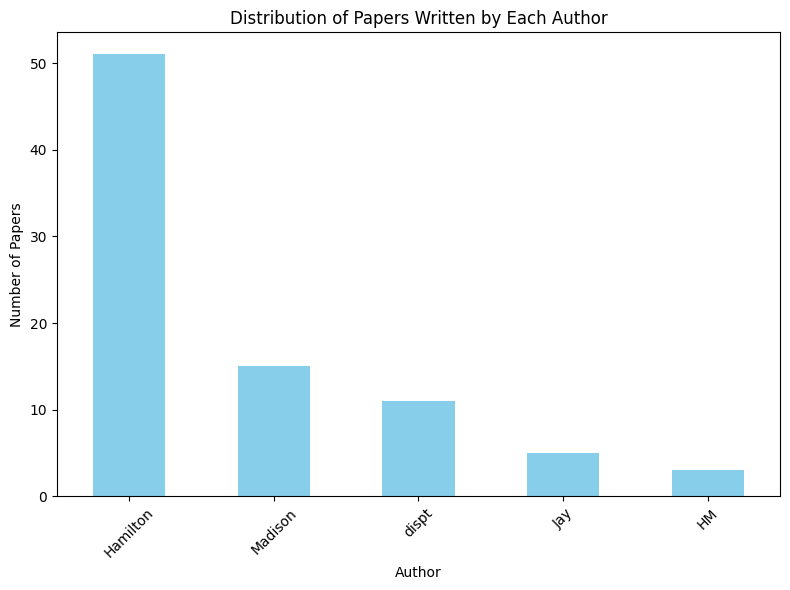

In [ ]:
import matplotlib.pyplot as plt
author_counts = authorship['target'].value_counts()
plt.figure(figsize=(8, 6))
author_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Papers Written by Each Author')
plt.xlabel('Author')
plt.ylabel('Number of Papers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Plot the distribution of sentence lengths for each author.

For this I need to use the corpus dataframe.

In [ ]:
corpus

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences,clean_sentences,token_sentences,tagged_sentences,lemmatized_sentences
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63,method guarding encroachment one department go...,"[method, guarding, encroachment, one, departme...","[(method, NN), (guarding, VBG), (encroachment,...","[method, guard, encroach, one, depart, govern,..."
0,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63,tuesday february,"[tuesday, february]","[(tuesday, JJ), (february, JJ)]","[tuesday, februari]"
0,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63,author alexander hamilton james madison,"[author, alexander, hamilton, james, madison]","[(author, NN), (alexander, NN), (hamilton, NN)...","[author, alexand, hamilton, jame, madison]"
0,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63,people state new york,"[people, state, new, york]","[(people, NNS), (state, NN), (new, JJ), (york,...","[peopl, state, new, york]"
0,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63,author note state virginia quoted last paper s...,"[author, note, state, virginia, quoted, last, ...","[(author, NN), (note, NN), (state, NN), (virgi...","[author, note, state, virginia, quot, last, pa..."
...,...,...,...,...,...,...,...,...,...,...,...
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"with regard to the court of chancery, that thi...",17,171,176,regard court chancery court generally try disp...,"[regard, court, chancery, court, generally, tr...","[(regard, NN), (court, NN), (chancery, NN), (c...","[regard, court, chanceri, court, gener, tri, d..."
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"The truth is, that references to a jury in tha...",31,172,176,truth reference jury court rarely happen case ...,"[truth, reference, jury, court, rarely, happen...","[(truth, NN), (reference, NN), (jury, NN), (co...","[truth, refer, juri, court, rare, happen, case..."
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,2.,1,173,176,,[],[],[]
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,It is true that the principles by which that r...,42,174,176,true principle relief governed reduced regular...,"[true, principle, relief, governed, reduced, r...","[(true, JJ), (principle, NN), (relief, NN), (g...","[true, principl, relief, govern, reduc, regula..."


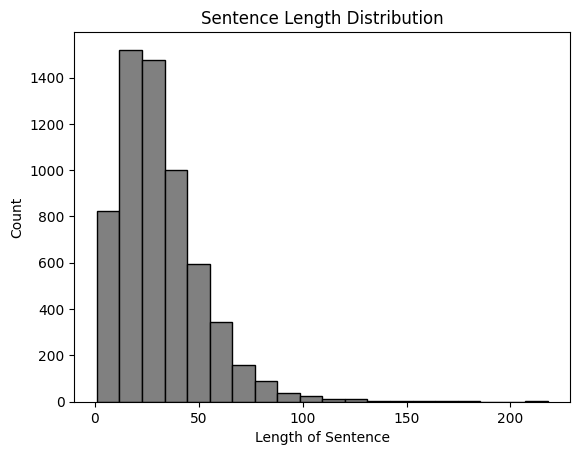

Unique Targets: ['dispt' 'HM' 'Hamilton' 'Jay' 'Madison']


In [ ]:
plt.hist(corpus['sentence_length'], bins = 20, edgecolor='black', color='grey')
plt.title('Sentence Length Distribution')
plt.xlabel('Length of Sentence')
plt.ylabel('Count')
plt.show()

unique_target = corpus['target'].unique()
print(f'Unique Targets: {unique_target}')

Now show a histogram for every unique author!


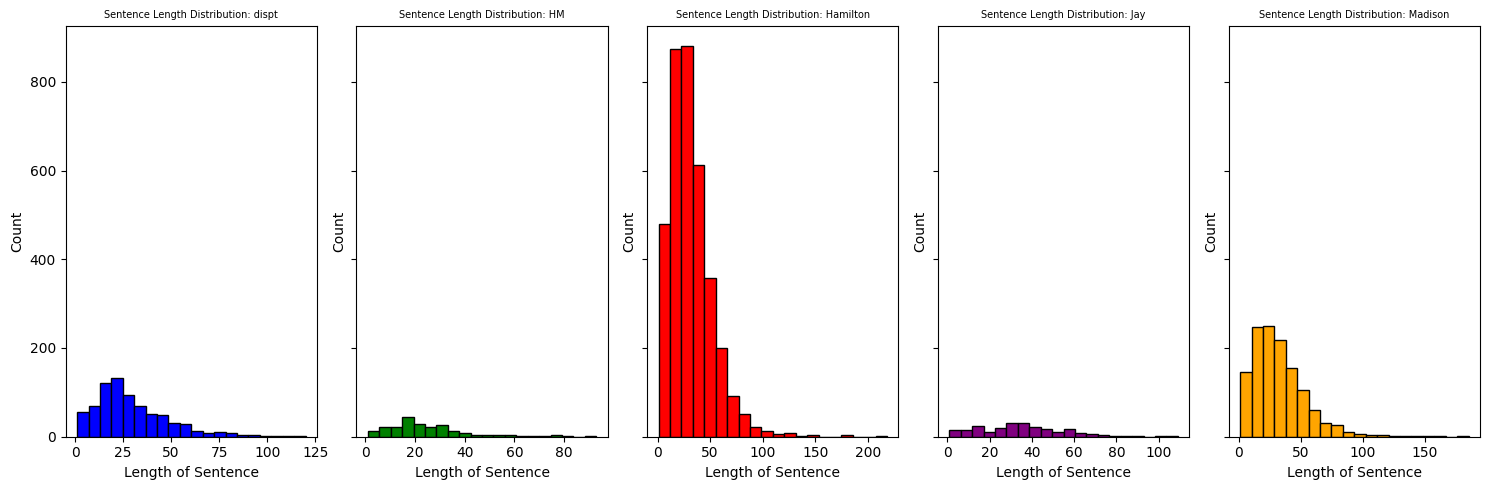

In [ ]:
import matplotlib.pyplot as plt

colors = ['blue', 'green', 'red', 'purple', 'orange']
unique_target = corpus['target'].unique()

fig, axes = plt.subplots(1, len(unique_target), figsize=(15, 5), sharey=True)

for i, target in enumerate(unique_target):
    ax = axes[i]
    ax.hist(corpus[corpus['target'] == target]['sentence_length'], bins=20, edgecolor='black', color=colors[i])
    ax.set_title(f'Sentence Length Distribution: {target}', fontsize=7)  # Adjust font size here
    ax.set_xlabel('Length of Sentence', fontsize=10)  # Adjust font size here
    ax.set_ylabel('Count', fontsize=10)  # Adjust font size here

plt.tight_layout()
plt.show()


Not a good idea for all of them to be on the same scale...

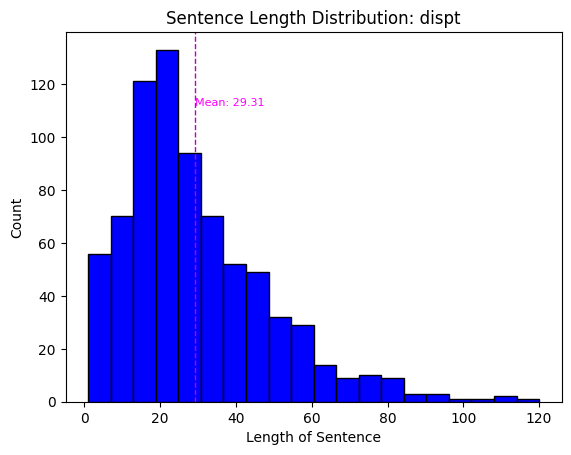

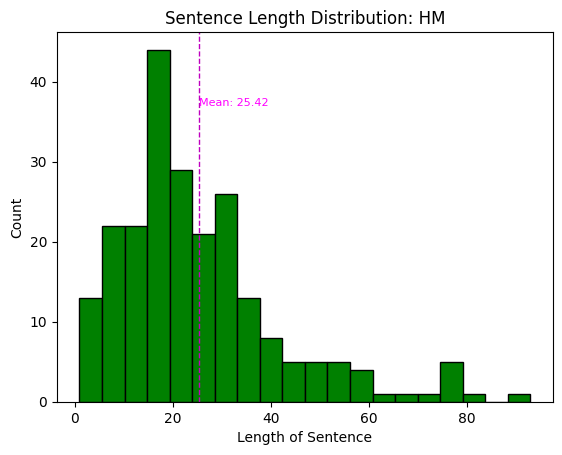

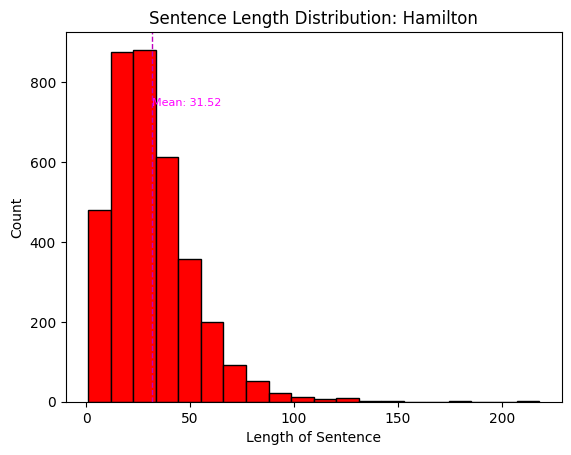

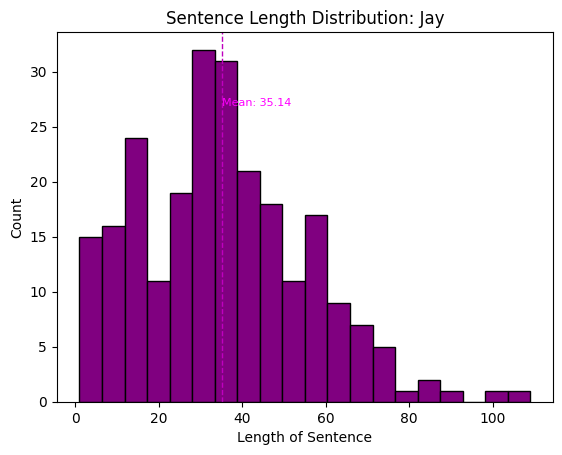

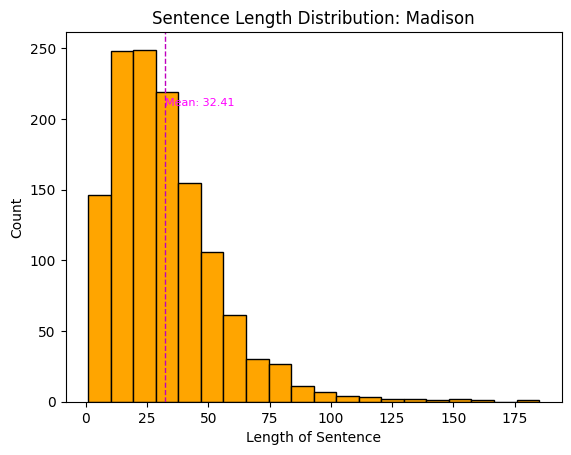

In [ ]:
import matplotlib.pyplot as plt

colors = ['blue', 'green', 'red', 'purple', 'orange']
unique_target = corpus['target'].unique()

for i, target in enumerate(unique_target):
    data = corpus[corpus['target'] == target]['sentence_length']
    plt.hist(data, bins=20, edgecolor='black', color=colors[i])
    plt.title(f'Sentence Length Distribution: {target}')

    # Calculate mean for each target
    mean = data.mean()

    # Plot mean and annotate it
    plt.axvline(mean, color='m', linestyle='--', linewidth=1)
    plt.text(mean, plt.gca().get_ylim()[1]*0.80, f'Mean: {mean:.2f}', fontsize=8, color='magenta')

    plt.xlabel('Length of Sentence')
    plt.ylabel('Count')
    plt.show()


### Prepare dataset for training

Prepare a training, validation, and test dataset. What is your X and y? What is the size of your training, validation, and test dataset?

In [ ]:
corpus

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences,clean_sentences,token_sentences,tagged_sentences,lemmatized_sentences
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63,method guarding encroachment one department go...,"[method, guarding, encroachment, one, departme...","[(method, NN), (guarding, VBG), (encroachment,...","[method, guard, encroach, one, depart, govern,..."
0,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63,tuesday february,"[tuesday, february]","[(tuesday, JJ), (february, JJ)]","[tuesday, februari]"
0,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63,author alexander hamilton james madison,"[author, alexander, hamilton, james, madison]","[(author, NN), (alexander, NN), (hamilton, NN)...","[author, alexand, hamilton, jame, madison]"
0,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63,people state new york,"[people, state, new, york]","[(people, NNS), (state, NN), (new, JJ), (york,...","[peopl, state, new, york]"
0,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63,author note state virginia quoted last paper s...,"[author, note, state, virginia, quoted, last, ...","[(author, NN), (note, NN), (state, NN), (virgi...","[author, note, state, virginia, quot, last, pa..."
...,...,...,...,...,...,...,...,...,...,...,...
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"with regard to the court of chancery, that thi...",17,171,176,regard court chancery court generally try disp...,"[regard, court, chancery, court, generally, tr...","[(regard, NN), (court, NN), (chancery, NN), (c...","[regard, court, chanceri, court, gener, tri, d..."
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"The truth is, that references to a jury in tha...",31,172,176,truth reference jury court rarely happen case ...,"[truth, reference, jury, court, rarely, happen...","[(truth, NN), (reference, NN), (jury, NN), (co...","[truth, refer, juri, court, rare, happen, case..."
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,2.,1,173,176,,[],[],[]
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,It is true that the principles by which that r...,42,174,176,true principle relief governed reduced regular...,"[true, principle, relief, governed, reduced, r...","[(true, JJ), (principle, NN), (relief, NN), (g...","[true, principl, relief, govern, reduc, regula..."


In [ ]:
from sklearn.model_selection import train_test_split

train_ratio = 0.7
test_ratio = 0.2

X_train, X_test, y_train, y_test = train_test_split(corpus['token_sentences'], corpus['target'], test_size= test_ratio, random_state=42)
print(f'Training samples: {len(X_train)}')
print(f'Validation samples: {len(X_test)}')

Training samples: 4887
Validation samples: 1222


#### Visualize some random samples

In [ ]:
import random
random_idx = random.randint(0, len(X_train))
print(f'Random sentence: {X_train.iloc[random_idx]}')
print(f'Author: {y_train.iloc[random_idx]}')

Random sentence: ['abuse', 'power', 'taxation', 'seems', 'provided', 'guarded', 'circumspection']
Author: Hamilton


In [ ]:
def split_tags(tagged_text):
  sent_list = []
  tag_list = []
  for sent, tag in tagged_text:
    sent_list.append(sent)
    tag_list.append(tag)
  return tag_list

corpus['tags'] = corpus['tagged_sentences'].apply(split_tags)

In [ ]:
corpus

,text,paper_id,target,sentences,sentence_length,sentence_index,total_sentences,clean_sentences,token_sentences,tagged_sentences,lemmatized_sentences,tags
0,Method of Guarding Against the Encroachments o...,49,dispt,Method of Guarding Against the Encroachments o...,25,0,63,method guarding encroachment one department go...,"[method, guarding, encroachment, one, departme...","[(method, NN), (guarding, VBG), (encroachment,...","[method, guard, encroach, one, depart, govern,...","[NN, VBG, JJ, CD, NN, NN, VBG, NNS, VBP, JJ, N..."
0,Method of Guarding Against the Encroachments o...,49,dispt,"Tuesday, February 5, 1788.",4,1,63,tuesday february,"[tuesday, february]","[(tuesday, JJ), (february, JJ)]","[tuesday, februari]","[JJ, JJ]"
0,Method of Guarding Against the Encroachments o...,49,dispt,Author: Alexander Hamilton or James Madison,6,2,63,author alexander hamilton james madison,"[author, alexander, hamilton, james, madison]","[(author, NN), (alexander, NN), (hamilton, NN)...","[author, alexand, hamilton, jame, madison]","[NN, NN, NN, NNS, VBP]"
0,Method of Guarding Against the Encroachments o...,49,dispt,To the People of the State of New York:,9,3,63,people state new york,"[people, state, new, york]","[(people, NNS), (state, NN), (new, JJ), (york,...","[peopl, state, new, york]","[NNS, NN, JJ, NN]"
0,Method of Guarding Against the Encroachments o...,49,dispt,"THE author of the ""Notes on the State of Virgi...",56,4,63,author note state virginia quoted last paper s...,"[author, note, state, virginia, quoted, last, ...","[(author, NN), (note, NN), (state, NN), (virgi...","[author, note, state, virginia, quot, last, pa...","[NN, NN, NN, NN, VBD, JJ, NN, VBD, JJ, NN, NN,..."
...,...,...,...,...,...,...,...,...,...,...,...,...
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"with regard to the court of chancery, that thi...",17,171,176,regard court chancery court generally try disp...,"[regard, court, chancery, court, generally, tr...","[(regard, NN), (court, NN), (chancery, NN), (c...","[regard, court, chanceri, court, gener, tri, d...","[NN, NN, NN, NN, RB, VB, JJ, NN, NN]"
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,"The truth is, that references to a jury in tha...",31,172,176,truth reference jury court rarely happen case ...,"[truth, reference, jury, court, rarely, happen...","[(truth, NN), (reference, NN), (jury, NN), (co...","[truth, refer, juri, court, rare, happen, case...","[NN, NN, NN, NN, RB, JJ, NN, JJ, NN, NN, NN, V..."
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,2.,1,173,176,,[],[],[],[]
84,The Judiciary Continued in Relation to Trial b...,83,Hamilton,It is true that the principles by which that r...,42,174,176,true principle relief governed reduced regular...,"[true, principle, relief, governed, reduced, r...","[(true, JJ), (principle, NN), (relief, NN), (g...","[true, principl, relief, govern, reduc, regula...","[JJ, NN, NN, VBD, VBN, JJ, NN, NN, JJ, JJ, JJ,..."


#### Plot the distribution of training and validation samples

Have you split the dataset in a stratified manner? Explain why it is important to split the dataset in a stratified manner. If you have not, explain why you did not split the dataset in a stratified manner. See the documentation for [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) for more information.

I did not stratify, so I will do that now looking at train_test_split sklearn documentation before plotting.

Splitting the dataset in a stratified manner is important because it ensures that both the training and test sets maintain the same class distribution as the original dataset. This helps prevent bias in the model's performance metrics by ensuring that minority classes are adequately represented in both sets. Consequently, it leads to more robust and generalizable models, as the performance evaluation will be reflective of the true distribution of the data.

In [ ]:
from sklearn.model_selection import train_test_split

train_ratio = 0.7
test_ratio = 0.2

X_train, X_test, y_train, y_test = train_test_split(corpus['token_sentences'], corpus['target'], test_size= test_ratio, stratify=corpus['target'],random_state=42)
print(f'Training samples: {len(X_train)}')
print(f'Validation samples: {len(X_test)}')

Training samples: 4887
Validation samples: 1222


#### Plot the datasets

<ipython-input-44-6ddff0842f39>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train, ax=ax[0], palette=palette)
<ipython-input-44-6ddff0842f39>:19: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.countplot(x=y_train, ax=ax[0], palette=palette)
<ipython-input-44-6ddff0842f39>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test, ax=ax[1], palette=palette)
<ipython-input-44-6ddff0842f39>:26: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.countplot(x=y_test, ax=ax[1], palette=palette)


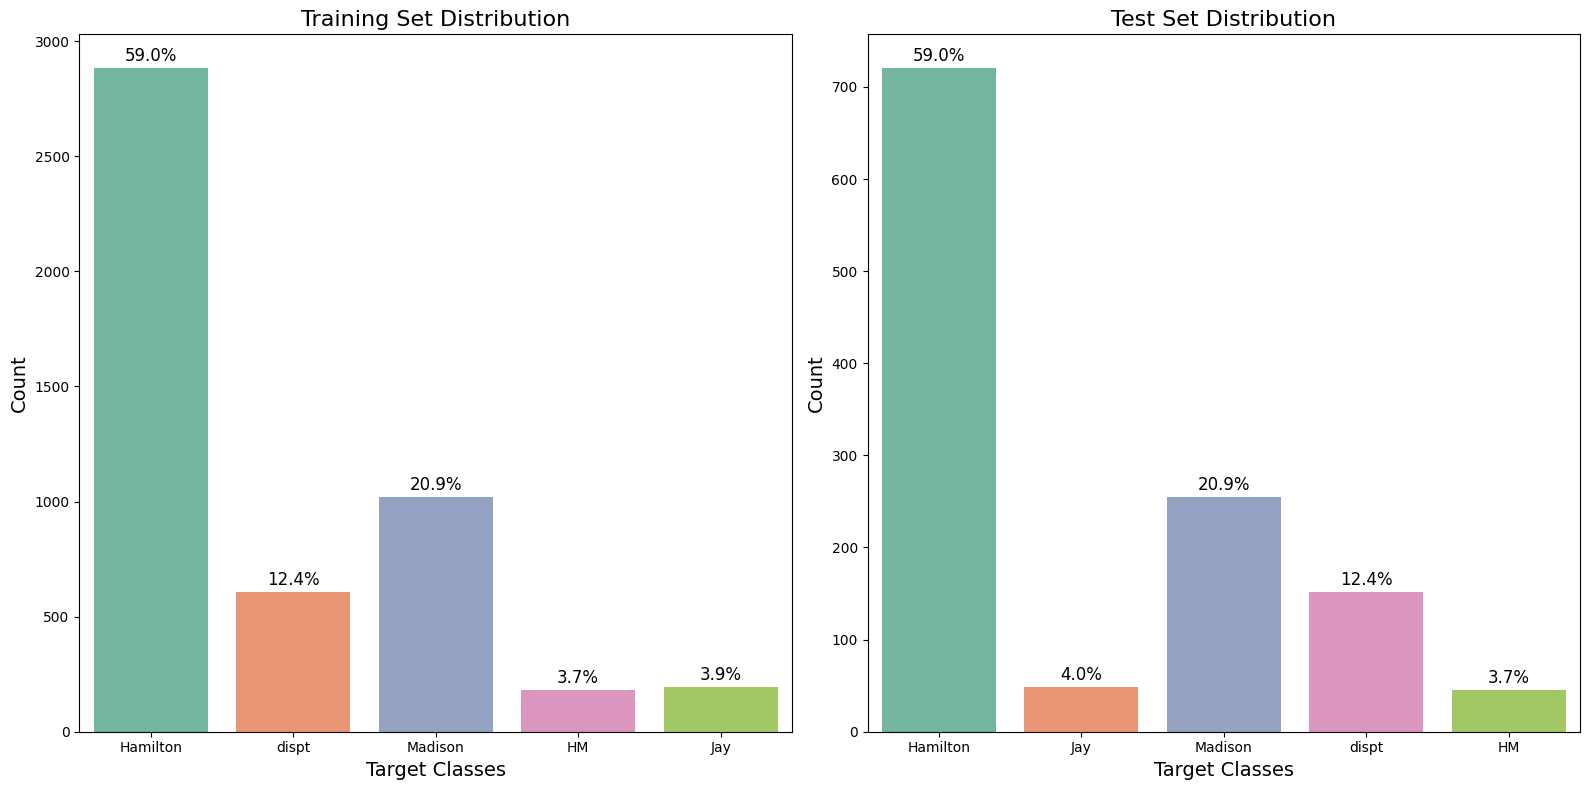

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 2, figsize=(16, 8))


palette = sns.color_palette('Set2')

def annotate_bars(ax):
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / sum([patch.get_height() for patch in ax.patches]):.1f}%'
        ax.annotate(percentage,
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=12, color='black',
                    xytext=(0, 5), textcoords='offset points')

# First plot: Training Set Distribution
sns.countplot(x=y_train, ax=ax[0], palette=palette)
ax[0].set_title('Training Set Distribution', fontsize=16)
ax[0].set_xlabel('Target Classes', fontsize=14)
ax[0].set_ylabel('Count', fontsize=14)
annotate_bars(ax[0])

# Second plot: Validation Set Distribution
sns.countplot(x=y_test, ax=ax[1], palette=palette)
ax[1].set_title('Test Set Distribution', fontsize=16)
ax[1].set_xlabel('Target Classes', fontsize=14)
ax[1].set_ylabel('Count', fontsize=14)
annotate_bars(ax[1])

# Adjust layout and show
plt.tight_layout()
plt.show()


Looks stratified to me!

#### Convert the target labels to one hot encodings

In [ ]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False)

y_train_ohe = ohe.fit_transform(y_train.values.reshape(-1,1))
y_val_ohe = ohe.fit_transform(y_test.values.reshape(-1,1))

print(f'One hot encoded training labels shape: {y_train_ohe.shape}')
print(f'One hot encoded validation labels shape: {y_val_ohe.shape}')


One hot encoded training labels shape: (4887, 5)
One hot encoded validation labels shape: (1222, 5)


In [ ]:
y_train_ohe[:5], y_train[:5]

(array([[0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0.]]),
 61    Hamilton
 8        dispt
 43    Hamilton
 16    Hamilton
 58    Hamilton
 Name: target, dtype: object)

#### Encode the labels

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_le = label_encoder.fit_transform(y_train)
y_val_le = label_encoder.fit_transform(y_test)

print(f'Label encoded training labels shape: {y_train_le.shape}')
print(f'Label encoded validation labels shape: {y_val_le.shape}')

Label encoded training labels shape: (4887,)
Label encoded validation labels shape: (1222,)


In [ ]:
for i in range(5):
    print(f'Original label: {y_train.iloc[i]} - Label encoded: {y_train_le[i]}')

Original label: Hamilton - Label encoded: 1
Original label: dispt - Label encoded: 4
Original label: Hamilton - Label encoded: 1
Original label: Hamilton - Label encoded: 1
Original label: Hamilton - Label encoded: 1


In [ ]:
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
num_classes, class_names

(5, array(['HM', 'Hamilton', 'Jay', 'Madison', 'dispt'], dtype=object))

# RNN Model

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
import keras

In [ ]:
tokenizer = keras.preprocessing.text.Tokenizer(oov_token='UNK')
tokenizer.fit_on_texts(X_train)
print(f'Vocabulary size: {len(tokenizer.word_index)}')

Vocabulary size: 6940


In [ ]:
tag_tokenizer = keras.preprocessing.text.Tokenizer()
tag_tokenizer.fit_on_texts(y_test)

In [ ]:
print(f'Authors: {len(tag_tokenizer.word_index)}')

Authors: 5


In [ ]:
tag_tokenizer.get_config()
tag_tokenizer.word_index

{'hamilton': 1, 'madison': 2, 'dispt': 3, 'jay': 4, 'hm': 5}

In [ ]:
X_train_seqs = tokenizer.texts_to_sequences(X_train)
print(f'X_train_seqs[0]: {X_train_seqs[0]}')
print(f'X_train[0]: {X_train.to_list()[0]}')

X_train_seqs[0]: [59, 4, 60, 67, 589, 2, 1186, 207, 30, 697, 8, 2408, 59]
X_train[0]: ['form', 'government', 'convention', 'several', 'smaller', 'state', 'agree', 'become', 'member', 'larger', 'one', 'intend', 'form']


In [ ]:
y_train_seqs = tag_tokenizer.texts_to_sequences(y_train)

In [ ]:
print(f'y_train_seqs[0]: {y_train_seqs[0]}')
print(f'y_train[0]: {y_train.to_list()[0]}')

y_train_seqs[0]: [1]
y_train[0]: Hamilton


In [ ]:
X_val_seqs = tokenizer.texts_to_sequences(X_test)
y_val_seqs = tag_tokenizer.texts_to_sequences(y_test)

In [ ]:
MAX_LEN = len(max(X_train_seqs, key=len))
print(f'Max length: {MAX_LEN}')

Max length: 101


In [ ]:
X_train_padded = keras.preprocessing.sequence.pad_sequences(X_train_seqs, maxlen=MAX_LEN, padding='post')
print(f'X_train_padded[0]: {X_train_padded[0]}')
y_train_padded = keras.preprocessing.sequence.pad_sequences(y_train_seqs, maxlen=MAX_LEN, padding='post')
X_val_padded = keras.preprocessing.sequence.pad_sequences(X_val_seqs, maxlen=MAX_LEN, padding='post')
y_val_padded = keras.preprocessing.sequence.pad_sequences(y_val_seqs, maxlen=MAX_LEN, padding='post')

X_train_padded[0]: [  59    4   60   67  589    2 1186  207   30  697    8 2408   59    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0]


In [ ]:
y_train_categories = keras.utils.to_categorical(y_train_padded)
print(f'y_train_categories[0]: {y_train_categories[0][0]}')

y_train_categories[0]: [0. 1. 0. 0. 0. 0.]


In [ ]:
## check labels
import numpy as np
idx = np.argmax(y_train_categories[0][0])
print(f'idx: {idx}')
print(f'Label: {tag_tokenizer.index_word[idx]}')

idx: 1
Label: hamilton


In [ ]:
# one hot encode the validation labels
y_val_categories = keras.utils.to_categorical(y_val_padded)

In [ ]:
num_tokens = len(tokenizer.word_index) + 1 # add 1 for padding
embedding_dim = 128
num_classes = len(tag_tokenizer.word_index) + 1 # add 1 for padding

In [ ]:
from tensorflow.keras import layers
tf.random.set_seed(42)

model = keras.Sequential()

model.add(layers.Embedding(input_dim=num_tokens,
                           output_dim=embedding_dim,
                           input_length=MAX_LEN,
                           mask_zero=True))

model.add(
    layers.Bidirectional(
        layers.LSTM(128,
                    return_sequences=True,
                    kernel_initializer=tf.keras.initializers.random_normal(seed=42)
                    )
        )
    )

model.add(layers.Dense(num_classes, activation='softmax', kernel_initializer=tf.keras.initializers.random_normal(seed=42)))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 101, 128)          888448    
                                                                 
 bidirectional (Bidirection  (None, 101, 256)          263168    
 al)                                                             
                                                                 
 dense (Dense)               (None, 101, 6)            1542      
                                                                 
Total params: 1153158 (4.40 MB)
Trainable params: 1153158 (4.40 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

history = model.fit(X_train_padded,
                    y_train_categories,
                    epochs=2,
                    batch_size=128,
                    validation_data=(X_val_padded, y_val_categories),
                    callbacks=[callback]
                    )

Epoch 1/2
39/39 [==============================] - 34s 568ms/step - loss: 0.7484 - accuracy: 0.9089 - val_loss: 0.1866 - val_accuracy: 0.9312
Epoch 2/2
39/39 [==============================] - 19s 495ms/step - loss: 0.1578 - accuracy: 0.9347 - val_loss: 0.1417 - val_accuracy: 0.9419


In [ ]:
print(X_train_padded.shape)
print(y_train_categories.shape)
print(X_val_padded.shape)
print(y_val_categories.shape)

(4887, 101)
(4887, 101, 6)
(1222, 101)
(1222, 101, 6)


In [ ]:
X_test_seqs = tokenizer.texts_to_sequences(X_test)
x_test_padded = keras.preprocessing.sequence.pad_sequences(X_test_seqs, maxlen=MAX_LEN, padding='post')

y_test_seqs = tag_tokenizer.texts_to_sequences(y_test)
y_test_padded = keras.preprocessing.sequence.pad_sequences(y_test_seqs, maxlen=MAX_LEN, padding='post')
y_test_categories = keras.utils.to_categorical(y_test_padded)

In [ ]:
model.evaluate(x_test_padded, y_test_categories)

39/39 [==============================] - 1s 21ms/step - loss: 0.1431 - accuracy: 0.9419


[0.1430681347846985, 0.941931426525116]

## Train a TF-IDF model

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

In [ ]:
X_train_processed = [' '.join(tokens) for tokens in X_train]

text_clf = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', SVC(kernel='linear', C=1.0, random_state=42))
])

# fit the model
text_clf.fit(X_train_processed, y_train_le)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('clf', SVC(kernel='linear', random_state=42))])

In [ ]:
x_val_processed = [' '.join(tokens) for tokens in X_test]
text_clf.score(x_val_processed, y_val_le)

0.6669394435351882

### Explain the TF-IDF model

- What is the TF-IDF model? / How does the TF-IDF model work?
- What are the hyperparameters of the TF-IDF model?
- How do you select the hyperparameters of the TF-IDF model?
- Why is it helpful to establish a baseline model?

TF-IDF stands for "term frequency-inverse document frequency". The "TF" part means that it examines the prevalence of certain words that we are concerned with relative to the entire document. The "IDF" part looks at how common or uncommon a word is amongst the corpus. So all in all, TF gives us information on how often a term appears in a document and IDF gives us information about the relative rarity of a term in the collection of documents. By multiplying these values together we can get our final TF-IDF value. The hyperparameters of the TF-IDF model according to scikit learn include *max_df*: ignores terms with a document frequency higher than this threshold to remove common terms, *min_df*: ignores terms with a document frequency lower than this threshold to remove rare terms, *max_features*: limits the number of features (terms) to the top terms ordered by frequency, *ngram_range*: specifies the range of n-values for n-grams to be extracted, *tokenizer*: overrides the string tokenization step while preserving the preprocessing and n-gram generation steps, *use_idf*: enables/disables inverse document frequency reweighting, *smooth_idf*: smooths IDF weights by adding one to document frequencies to prevent zero divisions, *norm*: specifies normalization ('l1', 'l2', or None) for the output vectors, and more. One can select the hyperparameters of the TF-IDF model through techniques like grid search or random search combined with cross-validation. One must find the best combination that yields the best performance on a validation set!
It's important to establish a baseline model is helpful because it provides a point of reference to evaluate the performance of more complex models. That way, you can see the improvements (if any) from the advanced models and adjust accordingly.

DONE